In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
import re 

font_path = "D:\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [28]:
OSAR_BOOTSTRAP_PATH = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\Bootstrapped stats"
FALLING_STATS_PATH  = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\Climbing_New\Compilation with delta\2025thesisstats"
MBON_CSV_PATH       = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"

OSAR_METRICS = [
    "PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR", "Log2 Speed ratio_Hg_OSAR",
    "Log2 Bout Speed ratio_Hg_OSAR", "Bout Number Index_Hg_OSAR",
    "Bout Duration ratio_Hg_OSAR", "Max Velocity ratio_Hg_OSAR",
]
METRICS = OSAR_METRICS  # default used by the reused load_bootstrap_data

OSAR_DISPLAY = {
    "PI_Hg_OSAR": "PI", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Log2 Speed ratio_Hg_OSAR": "Log2 Speed Ratio",
    "Log2 Bout Speed ratio_Hg_OSAR": "Log2 Bout Speed Ratio",
    "Bout Number Index_Hg_OSAR": "Bout Number Index",
    "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio",
}

# Climbing / Climbing metrics = short codes in the 'Metric' column of *_thesis_stats.csv
FALLING_METRICS = [
    "fallnumber", "speed", "height", "bspeed",
    "maxvelocity", "straightindex", "meanbout", "boutnumber",
]
FALLING_DISPLAY = {
    "fallnumber": "Fall number", "speed": "Speed", "height": "Max height climbed",
    "bspeed": "Bout speed", "pausepos": "Pause position", "maxvelocity": "Max velocity",
    "straightindex": "Straightness Index", "meanbout": "Duration of bouts",
    "boutnumber": "Number of bouts", "log2speed": "Log2 Speed Ratio",
    "log2bspeed": "Log2 Bout Speed Ratio", "boutnumber_index": "Bout Number Index",
    "boutduration_ratio": "Bout Duration Ratio", "maxvelocity_ratio": "Max Velocity Ratio",
}

## Shared vortex functions

In [ ]:
from vortexmap import *


## Climbing loader (data only)

In [10]:
def _extract_climbing_effect(sub):
    dd = sub[pd.to_numeric(sub["Delta-Delta/Delta-g"], errors="coerce").notna()]
    if len(dd):
        r = dd.iloc[-1]
        return (float(r["Delta-Delta/Delta-g"]),
                pd.to_numeric(r["Delta-Delta/Delta-g_CI_low"],  errors="coerce"),
                pd.to_numeric(r["Delta-Delta/Delta-g_CI_high"], errors="coerce"))
    es = sub[pd.to_numeric(sub["Effect Size"], errors="coerce").notna()]
    if len(es):
        r = es.iloc[-1]
        return (float(r["Effect Size"]),
                pd.to_numeric(r["Effect Size_CI_low"],  errors="coerce"),
                pd.to_numeric(r["Effect Size_CI_high"], errors="coerce"))
    return (np.nan, np.nan, np.nan)

def _synth_bootstrap_from_ci(effect, ci_low, ci_high, n=5000, seed=12):
    if effect is None or np.isnan(effect):
        return np.zeros(n)
    if (ci_low is not None and ci_high is not None and not np.isnan(ci_low)
            and not np.isnan(ci_high) and ci_high > ci_low):
        sd = (ci_high - ci_low) / (2 * 1.959964)
    else:
        sd = 0.15
    rng = np.random.default_rng(seed)
    return rng.normal(effect, max(sd, 1e-6), n)

def load_climbing_data(data_path, responders=None, metrics=None):
    metrics = metrics or FALLING_METRICS
    all_data = {}
    for filename in [f for f in os.listdir(data_path) if f.endswith("_thesis_stats.csv")]:
        parts = filename.replace("_thesis_stats.csv", "").split(" x ")
        if len(parts) != 2:
            continue
        mbon, responder = parts
        if responders and responder not in responders:
            continue
        if responder not in all_data:
            all_data[responder] = {m: {} for m in metrics}
        df = pd.read_csv(os.path.join(data_path, filename))
        for metric in metrics:
            sub = df[df["Metric"] == metric]
            if len(sub) == 0:
                continue
            eff, lo, hi = _extract_climbing_effect(sub)
            if eff is None or np.isnan(eff):
                continue
            all_data[responder][metric][mbon] = {
                "bootstrap": _synth_bootstrap_from_ci(eff, lo, hi),
                "effect": eff, "ci_low": lo, "ci_high": hi,
            }
    return all_data

def build_single_vortex(data, responder, mbon, metrics, n=11, chop_tail=2.5):
    """Build the spiral grid + effect values for ONE genotype (1 row x len(metrics))."""
    spirals = np.zeros((n, len(metrics) * n))
    mean_vals = np.full((1, len(metrics)), np.nan)
    for j, metric in enumerate(metrics):
        bootstrap = get_bootstrap(data, responder, metric, mbon)
        sampled = _sample_bootstrap(bootstrap, n, n, chop_tail)
        spirals[0:n, j * n:(j + 1) * n] = _spiralize(sampled, n, n)
        effect, _, _ = get_effect(data, responder, metric, mbon)
        if effect is not None:
            mean_vals[0, j] = effect
    return spirals, mean_vals

## Load data

In [30]:
RESPONDERS = ["ACR", "Chrimson2"]

osar_data    = load_bootstrap_data(OSAR_BOOTSTRAP_PATH, responders=RESPONDERS, metrics=OSAR_METRICS)
climbing_data = load_climbing_data(FALLING_STATS_PATH,    responders=RESPONDERS, metrics=FALLING_METRICS)

# match Vortex Maps.ipynb exclusions for OSAR
exclude = ["R76B09", "VT999036"]
for r in osar_data:
    for m in osar_data[r]:
        for key in exclude:
            osar_data[r][m].pop(key, None)

# build label table (MBON number / lobe)
csvfile = pd.read_csv(MBON_CSV_PATH).astype("string")
mbons_all = set()
for data in (osar_data, climbing_data):
    for r in data:
        mbons_all.update(get_mbons(data, r))
lobelocation = pd.DataFrame()
for m in sorted(mbons_all):
    row = {"MBON": m,
           "Lobe_location": find_number(csvfile, m, "Lobe"),
           "MBON_number": find_number(csvfile, m, "MBON number").strip()}
    lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
lobelocation = lobelocation.reset_index(drop=True)

print("OSAR genotypes (Chrimson2):", len(get_mbons(osar_data, "Chrimson2")))
print("Climbing genotypes (Chrimson2):", len(get_mbons(climbing_data, "Chrimson2")))

OSAR genotypes (Chrimson2): 43
Falling genotypes (Chrimson2): 46


## Plot ? pick a genotype

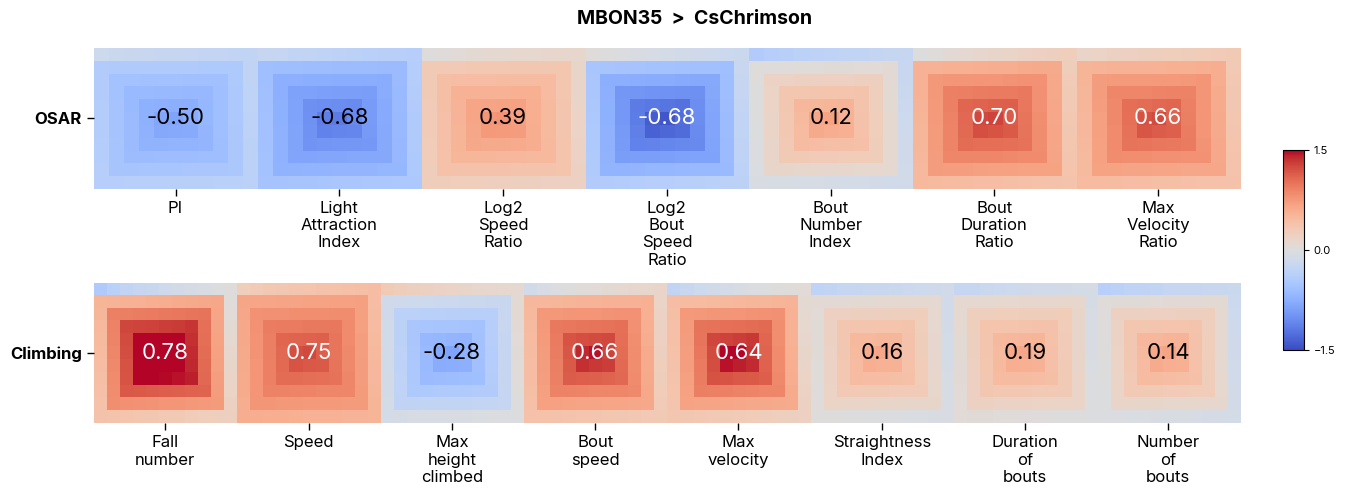

In [21]:
GENOTYPE  = "SS80974"      # driver / MBON
RESPONDER = "Chrimson2"    # "ACR" or "Chrimson2"

ANNOT_FONTSIZE  = 16   # effect-size numbers inside cells
XLABEL_FONTSIZE = 12    # metric names (bottom)
YLABEL_FONTSIZE = 12   # "OSAR" / "Climbing" row labels
TITLE_FONTSIZE  = 14
CBAR_FONTSIZE   = 8

N = 11
CMAP, VMIN, VMAX = "coolwarm", -1.5, 1.5

sp_o, mv_o = build_single_vortex(osar_data,    RESPONDER, GENOTYPE, OSAR_METRICS,    N)
sp_f, mv_f = build_single_vortex(climbing_data, RESPONDER, GENOTYPE, FALLING_METRICS, N)

fig, (axo, axf) = plt.subplots(2, 1, figsize=(14, 5))

for ax, sp, mv, mets, disp, row_label in [
    (axo, sp_o, mv_o, OSAR_METRICS,    OSAR_DISPLAY,    "OSAR"),
    (axf, sp_f, mv_f, FALLING_METRICS, FALLING_DISPLAY, "Climbing"),
]:
    ax.imshow(sp, cmap=CMAP, vmin=VMIN, vmax=VMAX, aspect="auto")
    for spine in ax.spines.values():
        spine.set_visible(False)
    # effect-size annotations
    for j in range(len(mets)):
        val = mv[0, j]
        txt = "" if np.isnan(val) else f"{val:.2f}"
        color = _get_text_color(sp, 0, j, N, CMAP, VMIN, VMAX)
        ax.text(j * N + (N - 1) / 2, (N - 1) / 2, txt, ha="center", va="center",
                fontsize=ANNOT_FONTSIZE, color=color)
    # x labels: horizontal, word-wrapped at every space
    ax.set_xticks([j * N + (N - 1) / 2 for j in range(len(mets))])
    ax.set_xticklabels([disp.get(m, m).replace(" ", "\n") for m in mets],
                       fontsize=XLABEL_FONTSIZE, rotation=0, ha="center")
    # y label
    ax.set_yticks([(N - 1) / 2])
    ax.set_yticklabels([row_label], fontsize=YLABEL_FONTSIZE, fontweight="bold")
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.tick_params(axis="both", which="major", length=5, width=1, color="black")
    ax.tick_params(axis="both", which="minor", length=0, width=0)

# title (MBON number > responder)
num = GENOTYPE
_info = lobelocation[lobelocation["MBON"] == GENOTYPE]
if len(_info):
    _cand = str(_info["MBON_number"].values[0]).strip()
    if _cand and _cand != "nan":
        num = _cand
rr = {"ACR": "GtACR1", "Chrimson2": "CsChrimson"}.get(RESPONDER, RESPONDER)
fig.suptitle(f"{num}  >  {rr}", fontsize=TITLE_FONTSIZE, fontweight="bold")

fig.tight_layout(rect=[0, 0, 0.9, 1])

# shared colorbar
cax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
cbar = fig.colorbar(axo.images[0], cax=cax, orientation="vertical")
cbar.set_ticks([VMIN, 0, VMAX])
cbar.ax.tick_params(labelsize=CBAR_FONTSIZE)

plt.show()

fig.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarclimbing\\images\\" + date + "_" + GENOTYPE + " x " + RESPONDER + "_doublevortexmaps.svg", bbox_inches="tight")

## Plot - both opsins (one genotype): OSAR & Climbing x CsChrimson/GtACR1

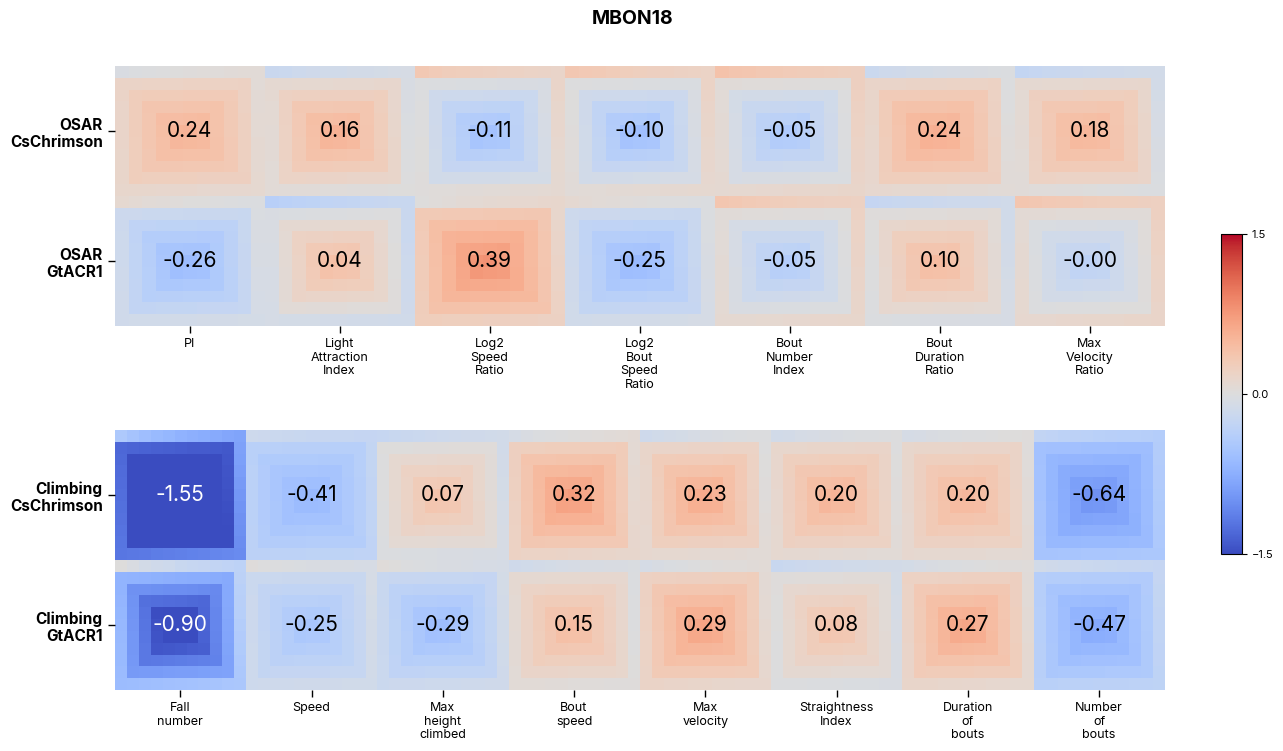

In [34]:
GENOTYPE = "SS01194"   # driver / MBON

ANNOT_FONTSIZE  = 15
XLABEL_FONTSIZE = 9
YLABEL_FONTSIZE = 11
TITLE_FONTSIZE  = 14
BLOCK_GAP       = 0.8   # vertical space between the OSAR block and the Climbing block.
                        # the two OSAR rows are flush; the two Climbing rows are flush.
N = 11
CMAP, VMIN, VMAX = "coolwarm", -1.5, 1.5

# (row label, data, responder, metrics, display, show_xlabels);  None = block spacer
rows = [
    ("OSAR\nCsChrimson",     osar_data,    "Chrimson2", OSAR_METRICS,    OSAR_DISPLAY,    False),
    ("OSAR\nGtACR1",         osar_data,    "ACR",       OSAR_METRICS,    OSAR_DISPLAY,    True),
    None,
    ("Climbing\nCsChrimson", climbing_data, "Chrimson2", FALLING_METRICS, FALLING_DISPLAY, False),
    ("Climbing\nGtACR1",     climbing_data, "ACR",       FALLING_METRICS, FALLING_DISPLAY, True),
]

heights = [BLOCK_GAP if r is None else 1 for r in rows]
fig, axes = plt.subplots(len(rows), 1, figsize=(14, 8),
                         gridspec_kw={"height_ratios": heights, "hspace": 0})

first_img = None
for ax, row in zip(axes, rows):
    if row is None:
        ax.axis("off")
        continue
    row_label, data, responder, mets, disp, show_x = row
    sp, mv = build_single_vortex(data, responder, GENOTYPE, mets, N)
    im = ax.imshow(sp, cmap=CMAP, vmin=VMIN, vmax=VMAX, aspect="auto")
    if first_img is None:
        first_img = im
    for spine in ax.spines.values():
        spine.set_visible(False)
    for j in range(len(mets)):
        val = mv[0, j]
        txt = "" if np.isnan(val) else f"{val:.2f}"
        color = _get_text_color(sp, 0, j, N, CMAP, VMIN, VMAX)
        ax.text(j * N + (N - 1) / 2, (N - 1) / 2, txt, ha="center", va="center",
                fontsize=ANNOT_FONTSIZE, color=color)
    ax.set_yticks([(N - 1) / 2])
    ax.set_yticklabels([row_label], fontsize=YLABEL_FONTSIZE, fontweight="bold")
    if show_x:
        ax.set_xticks([j * N + (N - 1) / 2 for j in range(len(mets))])
        ax.set_xticklabels([disp.get(m, m).replace(" ", "\n") for m in mets],
                           fontsize=XLABEL_FONTSIZE, rotation=0, ha="center")
    else:
        ax.set_xticks([])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.tick_params(axis="both", which="major", length=5, width=1, color="black")
    ax.tick_params(axis="both", which="minor", length=0, width=0)

num = GENOTYPE
_info = lobelocation[lobelocation["MBON"] == GENOTYPE]
if len(_info):
    _cand = str(_info["MBON_number"].values[0]).strip()
    if _cand and _cand != "nan":
        num = _cand
fig.suptitle(num, fontsize=TITLE_FONTSIZE, fontweight="bold")

fig.subplots_adjust(left=0.13, right=0.88, top=0.91, bottom=0.13)
cax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
cbar = fig.colorbar(first_img, cax=cax, orientation="vertical")
cbar.set_ticks([VMIN, 0, VMAX])
cbar.ax.tick_params(labelsize=8)
plt.show()